In [1]:
from __future__ import annotations

In [2]:
from IPython.display import display, HTML
display(HTML('<style>.container { width:100% !important; }</style>'))

In [3]:
import os
import datetime
import pathlib
import numpy as np
import sklearn.metrics
import tensorflow as tf
import keras
import sklearn.datasets
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import seaborn as sns
sns.set_style('dark')
sns.set_theme(rc={'figure.figsize': (10, 10), 'axes.grid': False})

N_CLASSES = 49

In [4]:
rng = np.random.default_rng()

In [5]:
def plot_grid(X, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    imgs = X[rng.choice(np.arange(X.shape[0]), size=ax.shape)].reshape(*ax.shape, 28, 28)
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            ax[i, j].imshow(imgs[i, j], cmap='gray')
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [6]:
def plot_grid_and_label(X, y, model, ncols=2, nrows=2, figsize=(10, 10), hide_axes=True, flatten_image=True, label_description=None):
    fig, ax = plt.subplots(ncols=ncols, nrows=nrows, figsize=figsize)
    idx = rng.choice(np.arange(X.shape[0]), size=ax.shape)
    imgs, labels = X[idx], y[idx]
    inputs = imgs.reshape(-1, *imgs.shape[2:])
    
    if flatten_image:
        inputs = inputs.reshape(nrows * ncols, -1)
        
    map_label = (lambda x: x) if label_description is None else (lambda x: label_description[x])
        
    preds = np.argmax(tf.nn.softmax(model.predict(inputs)), axis=-1).reshape(nrows, ncols)
    for i in range(ax.shape[0]):
        for j in range(ax.shape[1]):
            ax[i, j].imshow(imgs[i, j], cmap='gray')
            ax[i, j].set_title(f'label: {map_label(labels[i, j])}, prediction: {map_label(preds[i, j])}')
            if hide_axes:
                ax[i, j].get_xaxis().set_visible(False)
                ax[i, j].get_yaxis().set_visible(False)

In [7]:
label_description = [
     'A',   'I',   'U',  'E',  'O',
    'KA',  'KI',  'KU', 'KE', 'KO',
    'SA', 'SHI',  'SU', 'SE', 'SO',
    'TA', 'CHI', 'TSU', 'TE', 'TO',
    'NA',  'NI',  'NU', 'NE', 'NO',
    'HA',  'HI',  'FU', 'HE', 'HO',
    'MA',  'MI',  'MU', 'ME', 'MO',
    'YA',         'YU',       'YO',
    'RA',  'RI',  'RU', 'RE', 'RO',
    'WA',  'II',        'EE', 'WO',
     'N',  'IT'
]

In [8]:
X, y = sklearn.datasets.fetch_openml('Kuzushiji-49', version=1, return_X_y=True, as_frame=False, parser='auto', cache=True)
y = np.array(list(map(int, y)))
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [9]:
counts = { j: int(np.sum(y == i)) for i, j in enumerate(label_description) }
sorted(counts.items(), key=lambda x: x[-1]) # what to do with imbalanced classes?

[('EE', 456),
 ('II', 485),
 ('E', 903),
 ('YU', 1858),
 ('MU', 1998),
 ('HO', 2317),
 ('NU', 2399),
 ('RO', 2487),
 ('WA', 2787),
 ('NE', 2850),
 ('CHI', 2983),
 ('MI', 3558),
 ('ME', 3946),
 ('IT', 4097),
 ('SO', 4496),
 ('SE', 4843),
 ('KE', 5481),
 ('HI', 5968),
 ('A', 7000),
 ('I', 7000),
 ('U', 7000),
 ('O', 7000),
 ('KA', 7000),
 ('KI', 7000),
 ('KU', 7000),
 ('KO', 7000),
 ('SA', 7000),
 ('SHI', 7000),
 ('SU', 7000),
 ('TA', 7000),
 ('TSU', 7000),
 ('TE', 7000),
 ('TO', 7000),
 ('NA', 7000),
 ('NI', 7000),
 ('NO', 7000),
 ('HA', 7000),
 ('FU', 7000),
 ('HE', 7000),
 ('MA', 7000),
 ('MO', 7000),
 ('YA', 7000),
 ('YO', 7000),
 ('RA', 7000),
 ('RI', 7000),
 ('RU', 7000),
 ('RE', 7000),
 ('WO', 7000),
 ('N', 7000)]

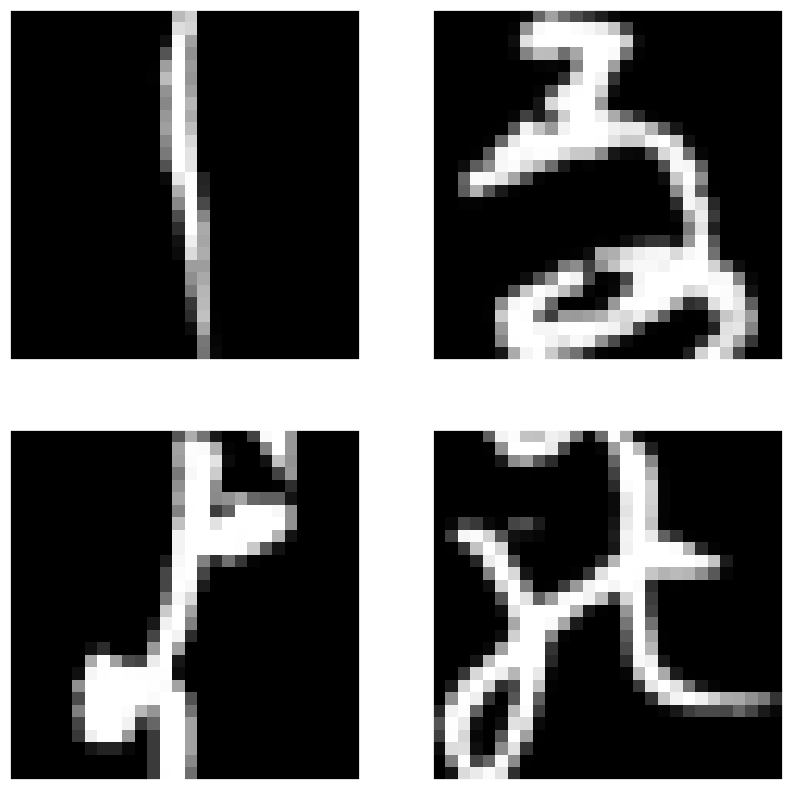

In [10]:
plot_grid(X_train)

## RandomOverSampler

In [11]:
class RandomOverSampler:
    def __init__(self, seed: int | None = None):
        self.seed = seed
        self.rng = None

    def _count_classes(self, y: np.ndarray) -> dict[int, int]:
        return { j: np.sum(y == i) for i, j in enumerate(np.unique(y)) }

    def fit_resample(self, X: np.ndarray, y: np.ndarray, target_count: int = -1) -> tuple[np.ndarray, np.ndarray]:
        self.rng = np.random.default_rng(self.seed)

        counts = self._count_classes(y)
        target_count = max(max(counts.values()), target_count or 0)

        sampled_X = []
        sampled_y = []

        for label, c in counts.items():
            needed = target_count - c
            label_idx = np.where(y == label)[0]
            sampled_idx = self.rng.choice(label_idx, size=needed, replace=True)
            sampled_X.append(X[sampled_idx])
            sampled_y.append(y[sampled_idx])

        resampled_X = np.concat([X] + sampled_X, axis=0)
        resampled_y = np.concat([y] + sampled_y, axis=0)
        
        return resampled_X, resampled_y


In [12]:
# create train and validation datasets, these datasets should use flattened images
ros = RandomOverSampler(42)

X_train_unb, X_test, y_train_unb, y_test = train_test_split(X, y, random_state=42)

X_train, y_train = ros.fit_resample(X_train_unb, y_train_unb)

In [13]:
ros._count_classes(y_train)

{np.int64(0): np.int64(5336),
 np.int64(1): np.int64(5336),
 np.int64(2): np.int64(5336),
 np.int64(3): np.int64(5336),
 np.int64(4): np.int64(5336),
 np.int64(5): np.int64(5336),
 np.int64(6): np.int64(5336),
 np.int64(7): np.int64(5336),
 np.int64(8): np.int64(5336),
 np.int64(9): np.int64(5336),
 np.int64(10): np.int64(5336),
 np.int64(11): np.int64(5336),
 np.int64(12): np.int64(5336),
 np.int64(13): np.int64(5336),
 np.int64(14): np.int64(5336),
 np.int64(15): np.int64(5336),
 np.int64(16): np.int64(5336),
 np.int64(17): np.int64(5336),
 np.int64(18): np.int64(5336),
 np.int64(19): np.int64(5336),
 np.int64(20): np.int64(5336),
 np.int64(21): np.int64(5336),
 np.int64(22): np.int64(5336),
 np.int64(23): np.int64(5336),
 np.int64(24): np.int64(5336),
 np.int64(25): np.int64(5336),
 np.int64(26): np.int64(5336),
 np.int64(27): np.int64(5336),
 np.int64(28): np.int64(5336),
 np.int64(29): np.int64(5336),
 np.int64(30): np.int64(5336),
 np.int64(31): np.int64(5336),
 np.int64(32): np.

In [24]:
class BalancedAccuracy(keras.metrics.MeanMetricWrapper):
    def __init__(self, n_classes: int, *args, **kwargs):
        self.n_classes = n_classes
        super().__init__(fn=self.__call__, *args, **kwargs)
        # Metric should be maximized during optimization.
        self._direction = "up"

    def __call__(self, y_true, y_pred):
        y_pred = tf.argmax(y_pred, axis=1)
        accs = []
        for cls in range(self.n_classes):
            mask = tf.equal(y_true, cls)
            masked = tf.boolean_mask(tf.equal(y_pred, cls), mask)
            
            cls_acc = tf.reduce_mean(tf.cast(masked, tf.float32))
            
            accs.append( tf.where(tf.math.is_nan(cls_acc), 0.0, cls_acc))
            
        return tf.reduce_mean(accs)
        
    def get_config(self):
        return {"name": self.name, "dtype": self.dtype}

## Flattened images
Use Dense layers

In [67]:
# create model, this model should accept a flattened image
x = inputs = keras.layers.Input((28*28,))
x = keras.layers.Dense(1024, activation='relu', name="dense_1")(x)
x = keras.layers.Dense(128, activation='relu', name="dense_2")(x)
x = keras.layers.Dense(N_CLASSES, activation='softmax', name="dense_softmax")(x)

model = keras.models.Model(inputs, x)

In [68]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_softmax (Dense)           │ (None, 49)             │         6,321 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941,361 (3.59 MB)

 Trainable params: 941,361 (3.59 MB)

 Non-trainable params: 0 (0.00 B)

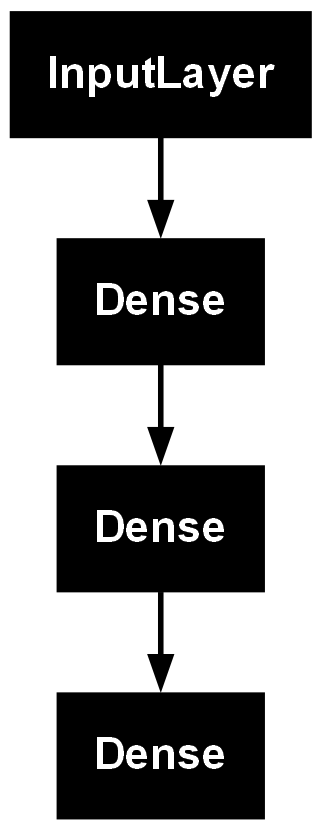

In [22]:
tf.keras.utils.plot_model(model)

In [46]:
logdir = pathlib.Path('logs/kuzushiji-49') / datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
logdir

WindowsPath('logs/kuzushiji-49/20260509-200755')

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(logdir / "model_flat.keras", save_best_only=True, monitor='val_loss'),
    tf.keras.callbacks.TensorBoard(logdir, update_freq=10)
]

In [69]:
# compile the model, make sure to add accuracy metric
model.compile(
    'nadam', 
    loss=keras.losses.SparseCategoricalCrossentropy(), 
    metrics=[
        BalancedAccuracy(N_CLASSES),
        # sklearn.metrics.balanced_accuracy_score,
        # keras.metrics.Accuracy
    ],
)

In [ ]:
# model.load_weights("logs/kuzushiji-49/20260509-200755/model_flat_hand_saved.keras")

In [ ]:
# model.save("logs/kuzushiji-49/20260509-200755/model_flat_hand_saved.keras")

In [51]:
# train the model, make sure to use callbacks and validation dataset
model.fit(
    X_train, y_train, 
    batch_size=64, 
    epochs=10,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
)

Epoch 1/10
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - balanced_accuracy_1: 0.0587 - loss: 3.8037 - val_balanced_accuracy_1: 0.0628 - val_loss: 3.5352
Epoch 2/10
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 45s 11ms/step - balanced_accuracy_1: 0.1191 - loss: 3.1303 - val_balanced_accuracy_1: 0.1741 - val_loss: 2.5317
Epoch 3/10
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - balanced_accuracy_1: 0.3802 - loss: 1.7863 - val_balanced_accuracy_1: 0.4456 - val_loss: 1.4189
Epoch 4/10
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - balanced_accuracy_1: 0.5314 - loss: 1.1078 - val_balanced_accuracy_1: 0.4966 - val_loss: 1.1423
Epoch 5/10
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - balanced_accuracy_1: 0.5739 - loss: 0.8973 - val_balanced_accuracy_1: 0.5259 - val_loss: 1.0661
Epoch 6/10
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - balanced_accuracy_1: 0.5970 - loss: 0.7824 - val_balanced_accuracy_1: 0.5352 - val_loss: 1.0438
Epoch 7/10
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - balanced_accuracy_

In [71]:
model.evaluate(X_test, y_test)

2117/2117 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - balanced_accuracy_2: 0.3759 - loss: 1.0780


[1.0780071020126343, 0.3758540749549866]

In [53]:
images = X_test.reshape(-1, 28, 28, 1) # normalize if needed

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


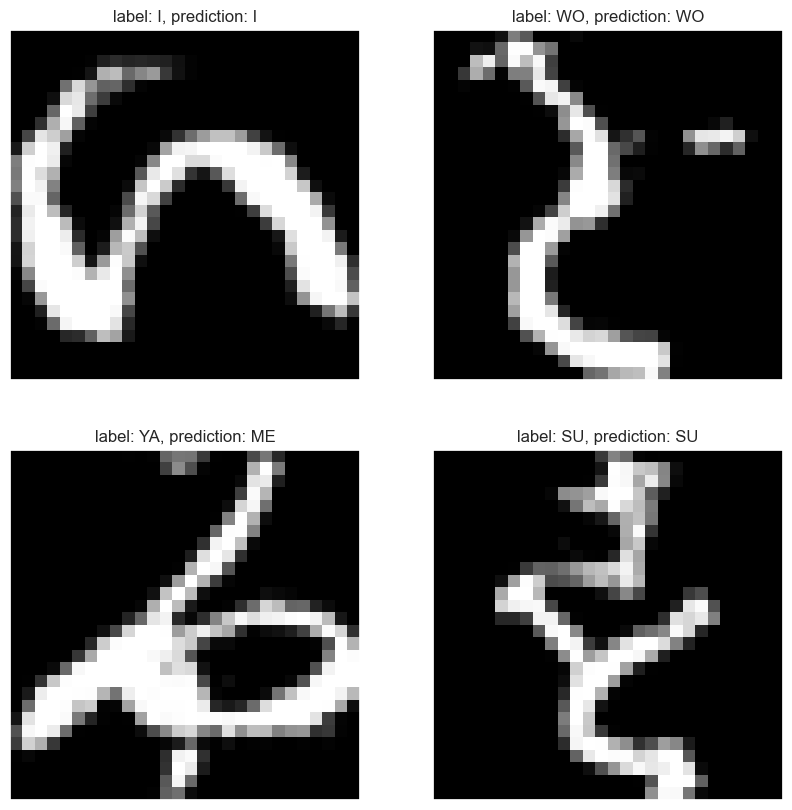

In [64]:
plot_grid_and_label(images, y_test, model, label_description=label_description)

In [55]:
y_pred = model.predict(X_test)

2117/2117 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [56]:
y_pred = np.argmax(y_pred, axis=1)

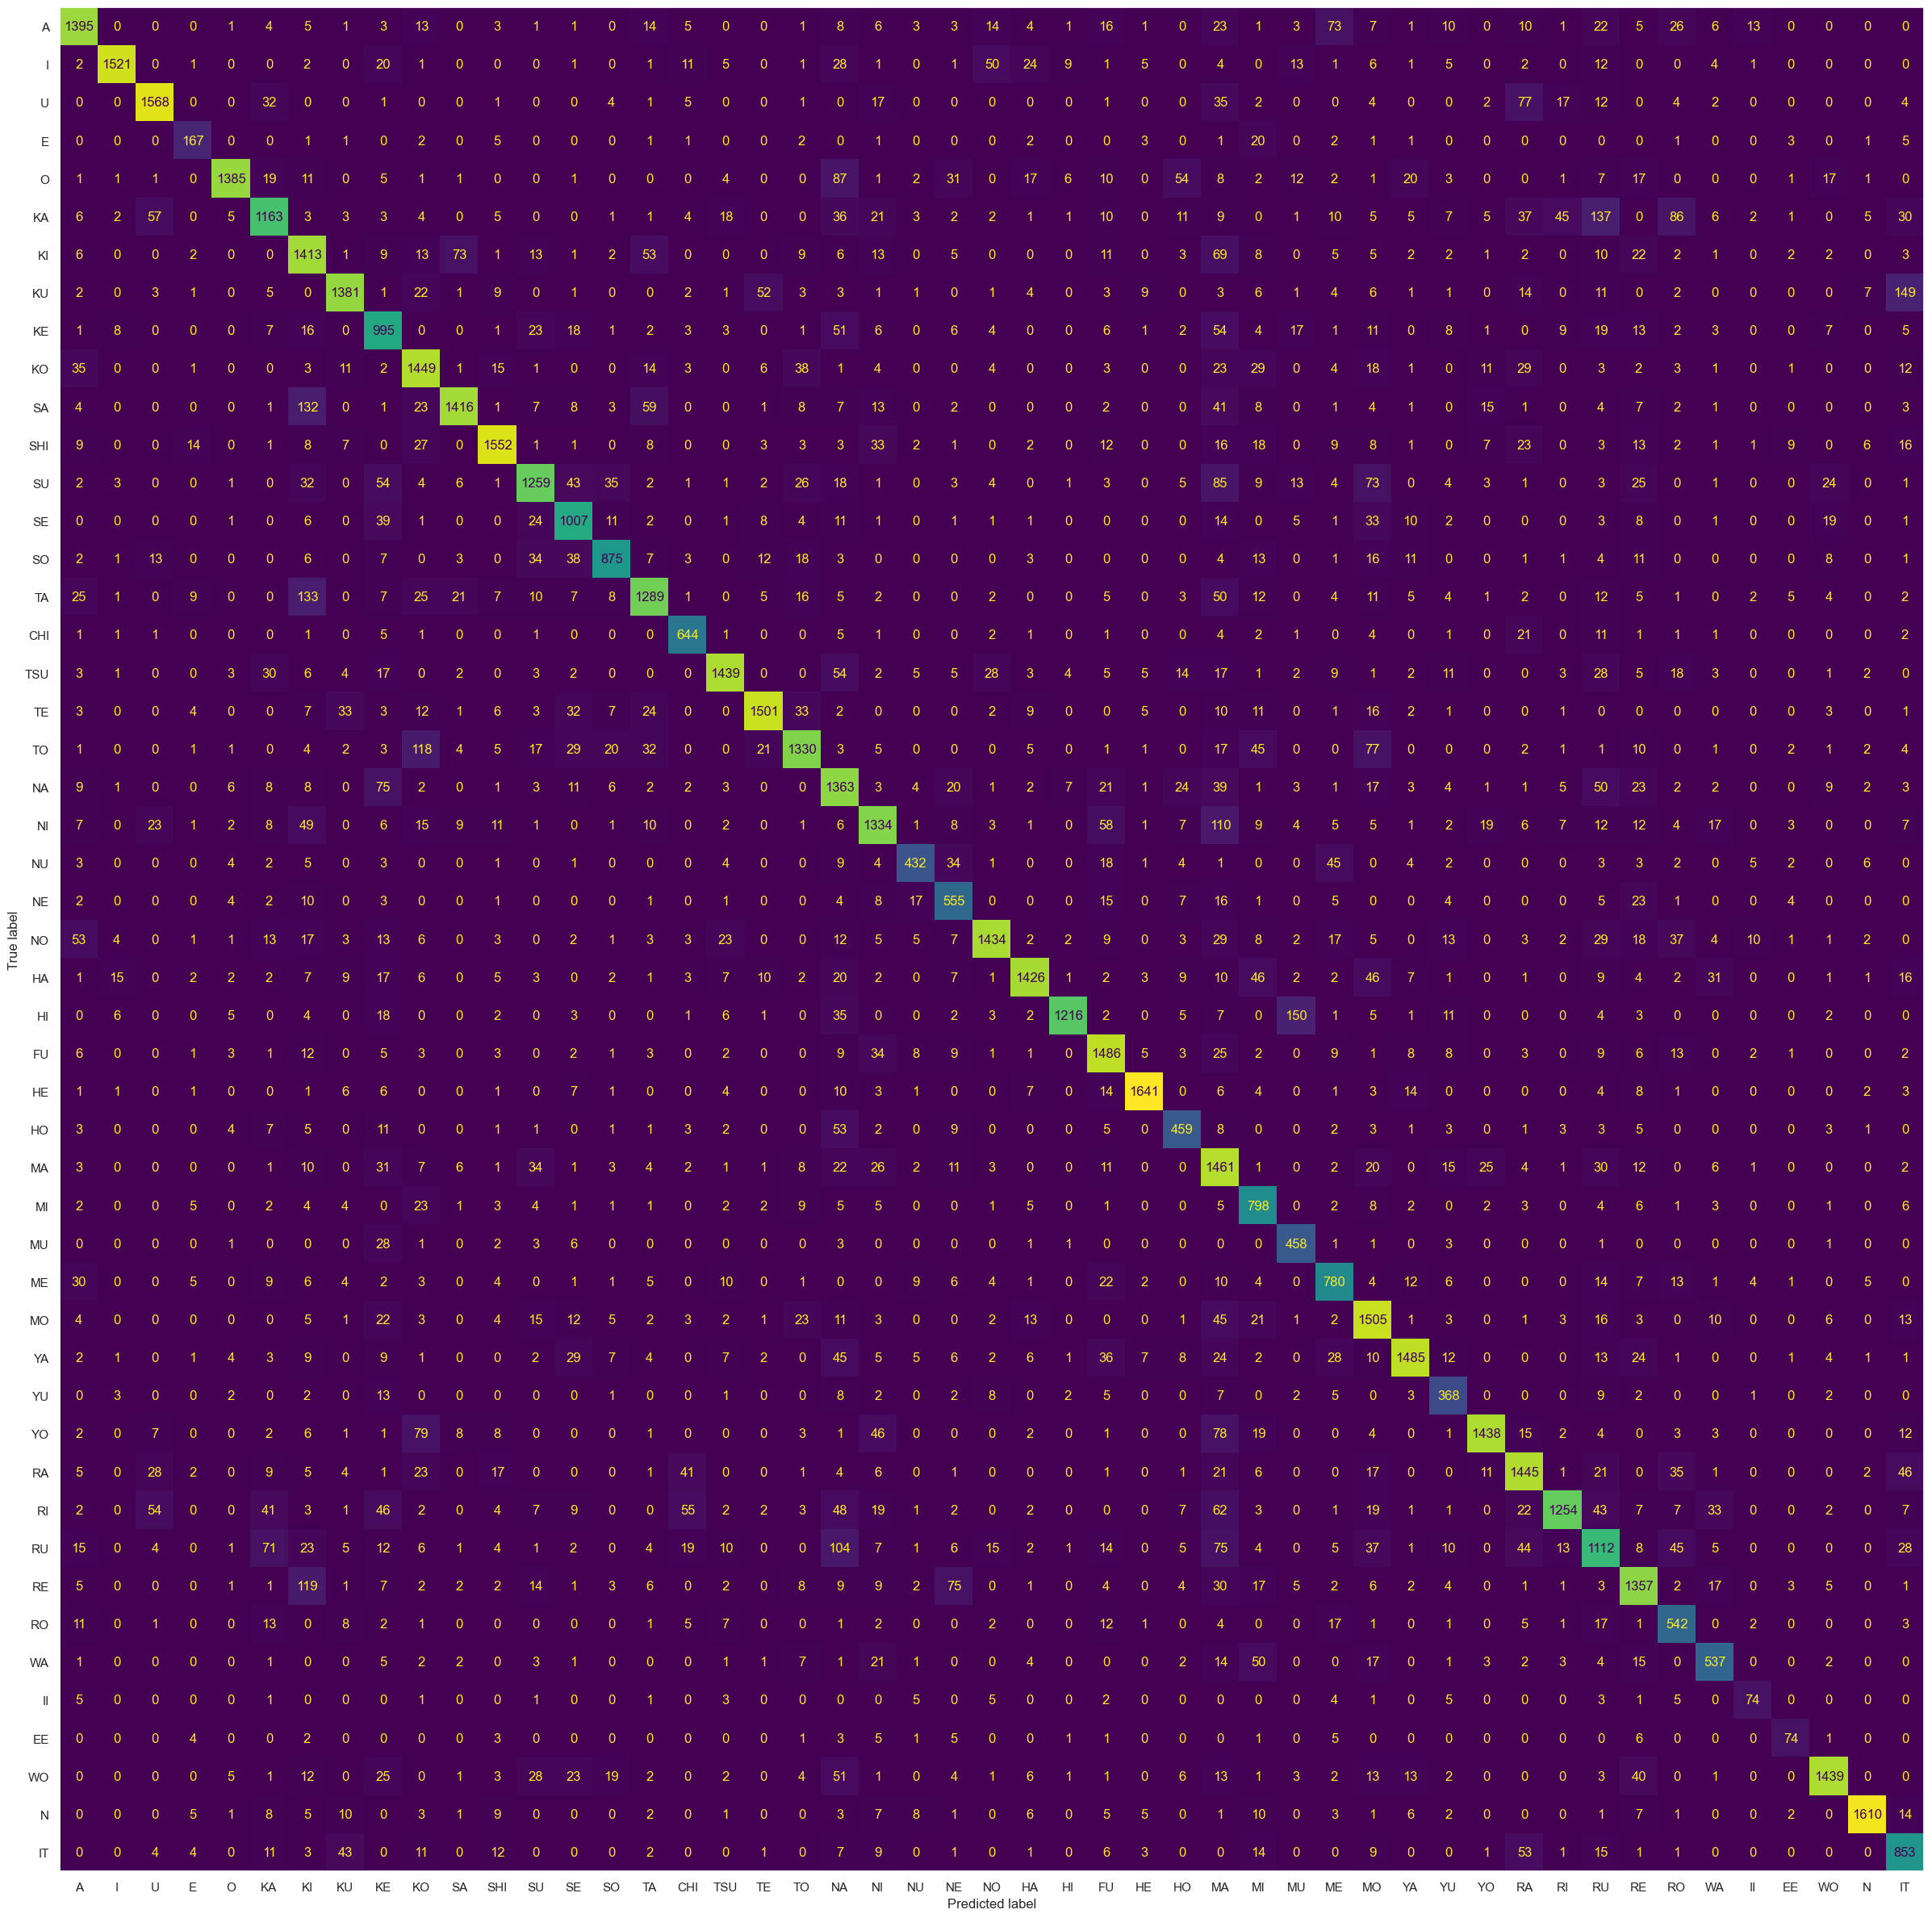

In [57]:
_, ax = plt.subplots(figsize=(30, 30))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_description, ax=ax, colorbar=False)

##### Balanced accuracy

In [75]:
ba = BalancedAccuracy(N_CLASSES)
ba(y_test, model.predict(X_test))

2117/2117 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


<tf.Tensor: shape=(), dtype=float32, numpy=0.8009946942329407>

In [72]:
accuracy = y_test == y_pred
np.mean([np.mean(accuracy[y_test == i]) for i in range(49)])

np.float64(0.800994725654993)

## Actual images
Use Conv2D layers with Dense layer on top

In [14]:
# create train and validation datasets, these datasets should use 28x28x1 images
X_train2 = X_train.reshape(-1, 28, 28, 1)
X_test2 = X_test.reshape(-1, 28, 28, 1)
X_train2.shape, X_test2.shape

((261464, 28, 28, 1), (67728, 28, 28, 1))

In [53]:
def res_block(inp, dim: int, is_first: bool=False):
    x = inp

    # x = keras.layers.Conv2D(dim // 4, 1, strides=1 + is_first, activation='relu')(x)
    # x = keras.layers.Conv2D(dim // 4, 3, activation='relu')(x)
    # x = keras.layers.Conv2D(dim, 1)(x)
    # x = keras.layers.Add()([x, inp])

    x = keras.layers.Conv2D(dim, 3, strides=1 + is_first, activation='relu', padding='same')(x)
    x = keras.layers.Conv2D(dim, 3, padding='same')(x)
    if (not is_first):
        x = keras.layers.Add()([x, inp])

    return x

In [58]:
# create model, this model should accept a 28x28x1 image

x = inputs = keras.layers.Input((28, 28, 1))

x = keras.layers.Conv2D(64, 3, strides=2, padding='same')(x)
x = keras.layers.AvgPool2D(3, strides=2, padding='same')(x)

x = res_block(x, 64)
x = res_block(x, 64)

x = res_block(x, 128, True)
x = res_block(x, 128)

x = keras.layers.AvgPool2D(2)(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(1000, activation='relu')(x)
x = keras.layers.Dense(N_CLASSES, activation='softmax', name="dense_softmax")(x)

model2 = keras.models.Model(inputs, x)

In [59]:
model2.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 14, 14,    │        640 │ input_layer_16[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_… │ (None, 7, 7, 64)  │          0 │ conv2d_63[0][0]   │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 7, 7, 64)  │     36,928 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 7, 7, 64)  │     36,928 │ conv2d_64[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 7, 7, 64)  │          0 │ conv2d_65[0][0],  │
│                     │                   │            │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 7, 7, 64)  │     36,928 │ add_19[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_67 (Conv2D)  │ (None, 7, 7, 64)  │     36,928 │ conv2d_66[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 7, 7, 64)  │          0 │ conv2d_67[0][0],  │
│                     │                   │            │ add_19[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_68 (Conv2D)  │ (None, 4, 4, 128) │     73,856 │ add_20[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_69 (Conv2D)  │ (None, 4, 4, 128) │    147,584 │ conv2d_68[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_70 (Conv2D)  │ (None, 4, 4, 128) │    147,584 │ conv2d_69[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_71 (Conv2D)  │ (None, 4, 4, 128) │    147,584 │ conv2d_70[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_21 (Add)        │ (None, 4, 4, 128) │          0 │ conv2d_71[0][0],  │
│                     │                   │            │ conv2d_69[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_… │ (None, 2, 2, 128) │          0 │ add_21[0][0]      │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 512)       │          0 │ average_pooling2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1000)      │    513,000 │ flatten_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_softmax       │ (None, 49)        │     49,049 │ dense[0][0]       │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,227,009 (4.68 MB)

 Trainable params: 1,227,009 (4.68 MB)

 Non-trainable params: 0 (0.00 B)

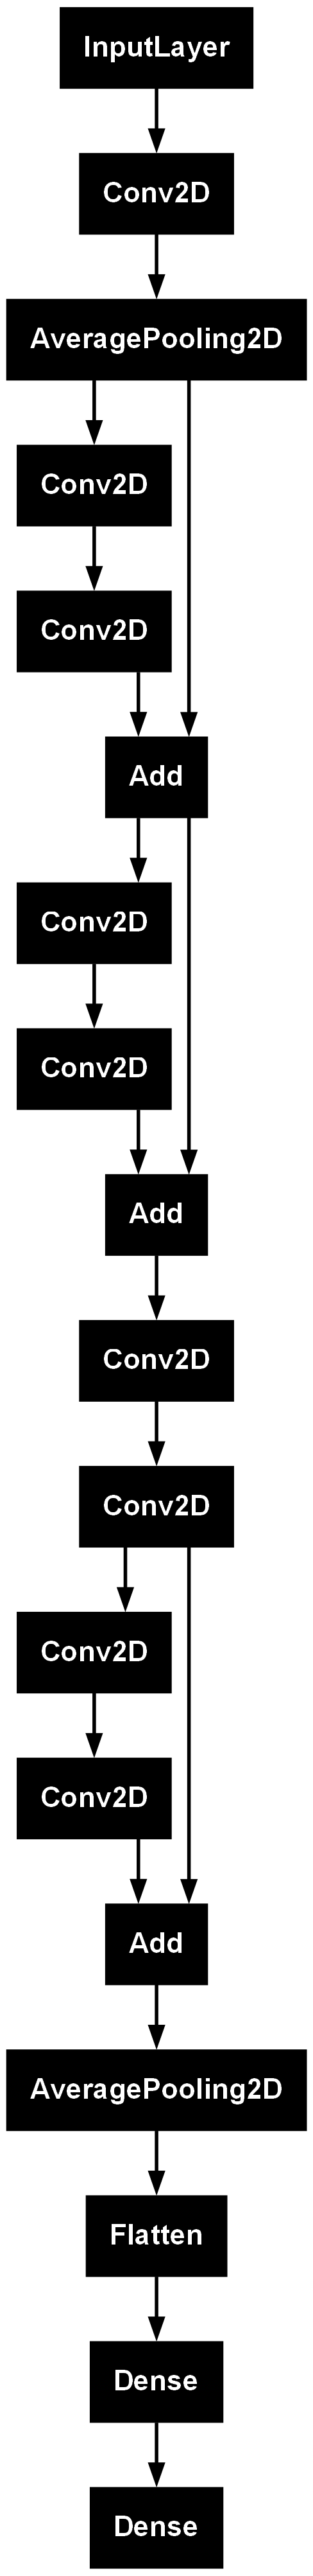

In [60]:
tf.keras.utils.plot_model(model2)

In [61]:
logdir = pathlib.Path('logs/kuzushiji-49') / datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
logdir

WindowsPath('logs/kuzushiji-49/20260509-211957')

In [62]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(logdir / "model_2d.keras", save_best_only=True, monitor='val_loss'),
    tf.keras.callbacks.TensorBoard(logdir, update_freq=10)
]

In [63]:
# compile the model, make sure to add accuracy metric
model2.compile(
    'nadam', 
    loss=keras.losses.SparseCategoricalCrossentropy(), 
    metrics=[
        BalancedAccuracy(N_CLASSES),
    ],
)

In [ ]:
# model2.load_weights("logs/kuzushiji-49/211957-200755/model_2d_hand_saved.keras")

In [ ]:
# model2.save("logs/kuzushiji-49/20260509-211957/model_2d_hand_saved.keras")

In [64]:
# train the model, make sure to use callbacks and validation dataset
model2.fit(
    X_train2, y_train, 
    batch_size=64, 
    epochs=10,
    validation_data=(X_test2, y_test),
    callbacks=callbacks,
)

Epoch 1/10
4086/4086 ━━━━━━━━━━━━━━━━━━━━ 104s 24ms/step - balanced_accuracy_4: 0.6250 - loss: 0.5558 - val_balanced_accuracy_4: 0.5962 - val_loss: 0.4811
Epoch 2/10
4086/4086 ━━━━━━━━━━━━━━━━━━━━ 99s 24ms/step - balanced_accuracy_4: 0.6568 - loss: 0.3715 - val_balanced_accuracy_4: 0.6121 - val_loss: 0.4150
Epoch 3/10
4086/4086 ━━━━━━━━━━━━━━━━━━━━ 101s 25ms/step - balanced_accuracy_4: 0.6639 - loss: 0.3426 - val_balanced_accuracy_4: 0.6082 - val_loss: 0.4539
Epoch 4/10
4086/4086 ━━━━━━━━━━━━━━━━━━━━ 103s 25ms/step - balanced_accuracy_4: 0.6667 - loss: 0.3300 - val_balanced_accuracy_4: 0.6253 - val_loss: 0.3746
Epoch 5/10
4086/4086 ━━━━━━━━━━━━━━━━━━━━ 106s 26ms/step - balanced_accuracy_4: 0.6693 - loss: 0.3234 - val_balanced_accuracy_4: 0.6045 - val_loss: 0.5576
Epoch 6/10
4086/4086 ━━━━━━━━━━━━━━━━━━━━ 118s 29ms/step - balanced_accuracy_4: 0.6715 - loss: 0.3170 - val_balanced_accuracy_4: 0.6166 - val_loss: 0.4514
Epoch 7/10
4086/4086 ━━━━━━━━━━━━━━━━━━━━ 102s 25ms/step - balanced_acc

In [28]:
images = X_test2.reshape(-1, 28, 28, 1) # normalize if needed

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


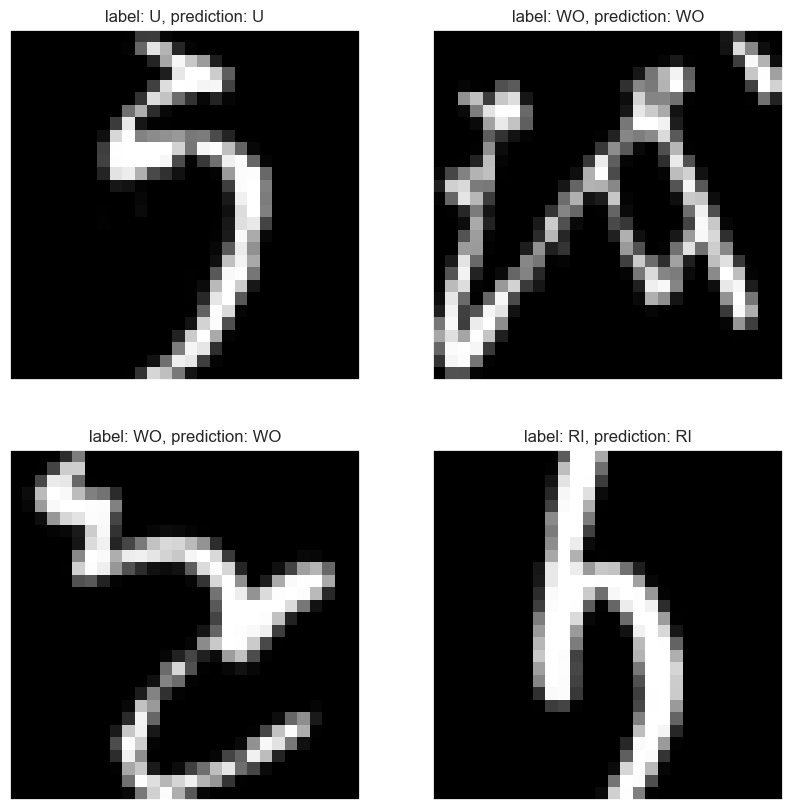

In [65]:
plot_grid_and_label(images, y_test, model2, label_description=label_description, flatten_image=False)

In [66]:
y_pred = model2.predict(X_test2)

2117/2117 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step


In [67]:
y_pred = np.argmax(y_pred, axis=1)

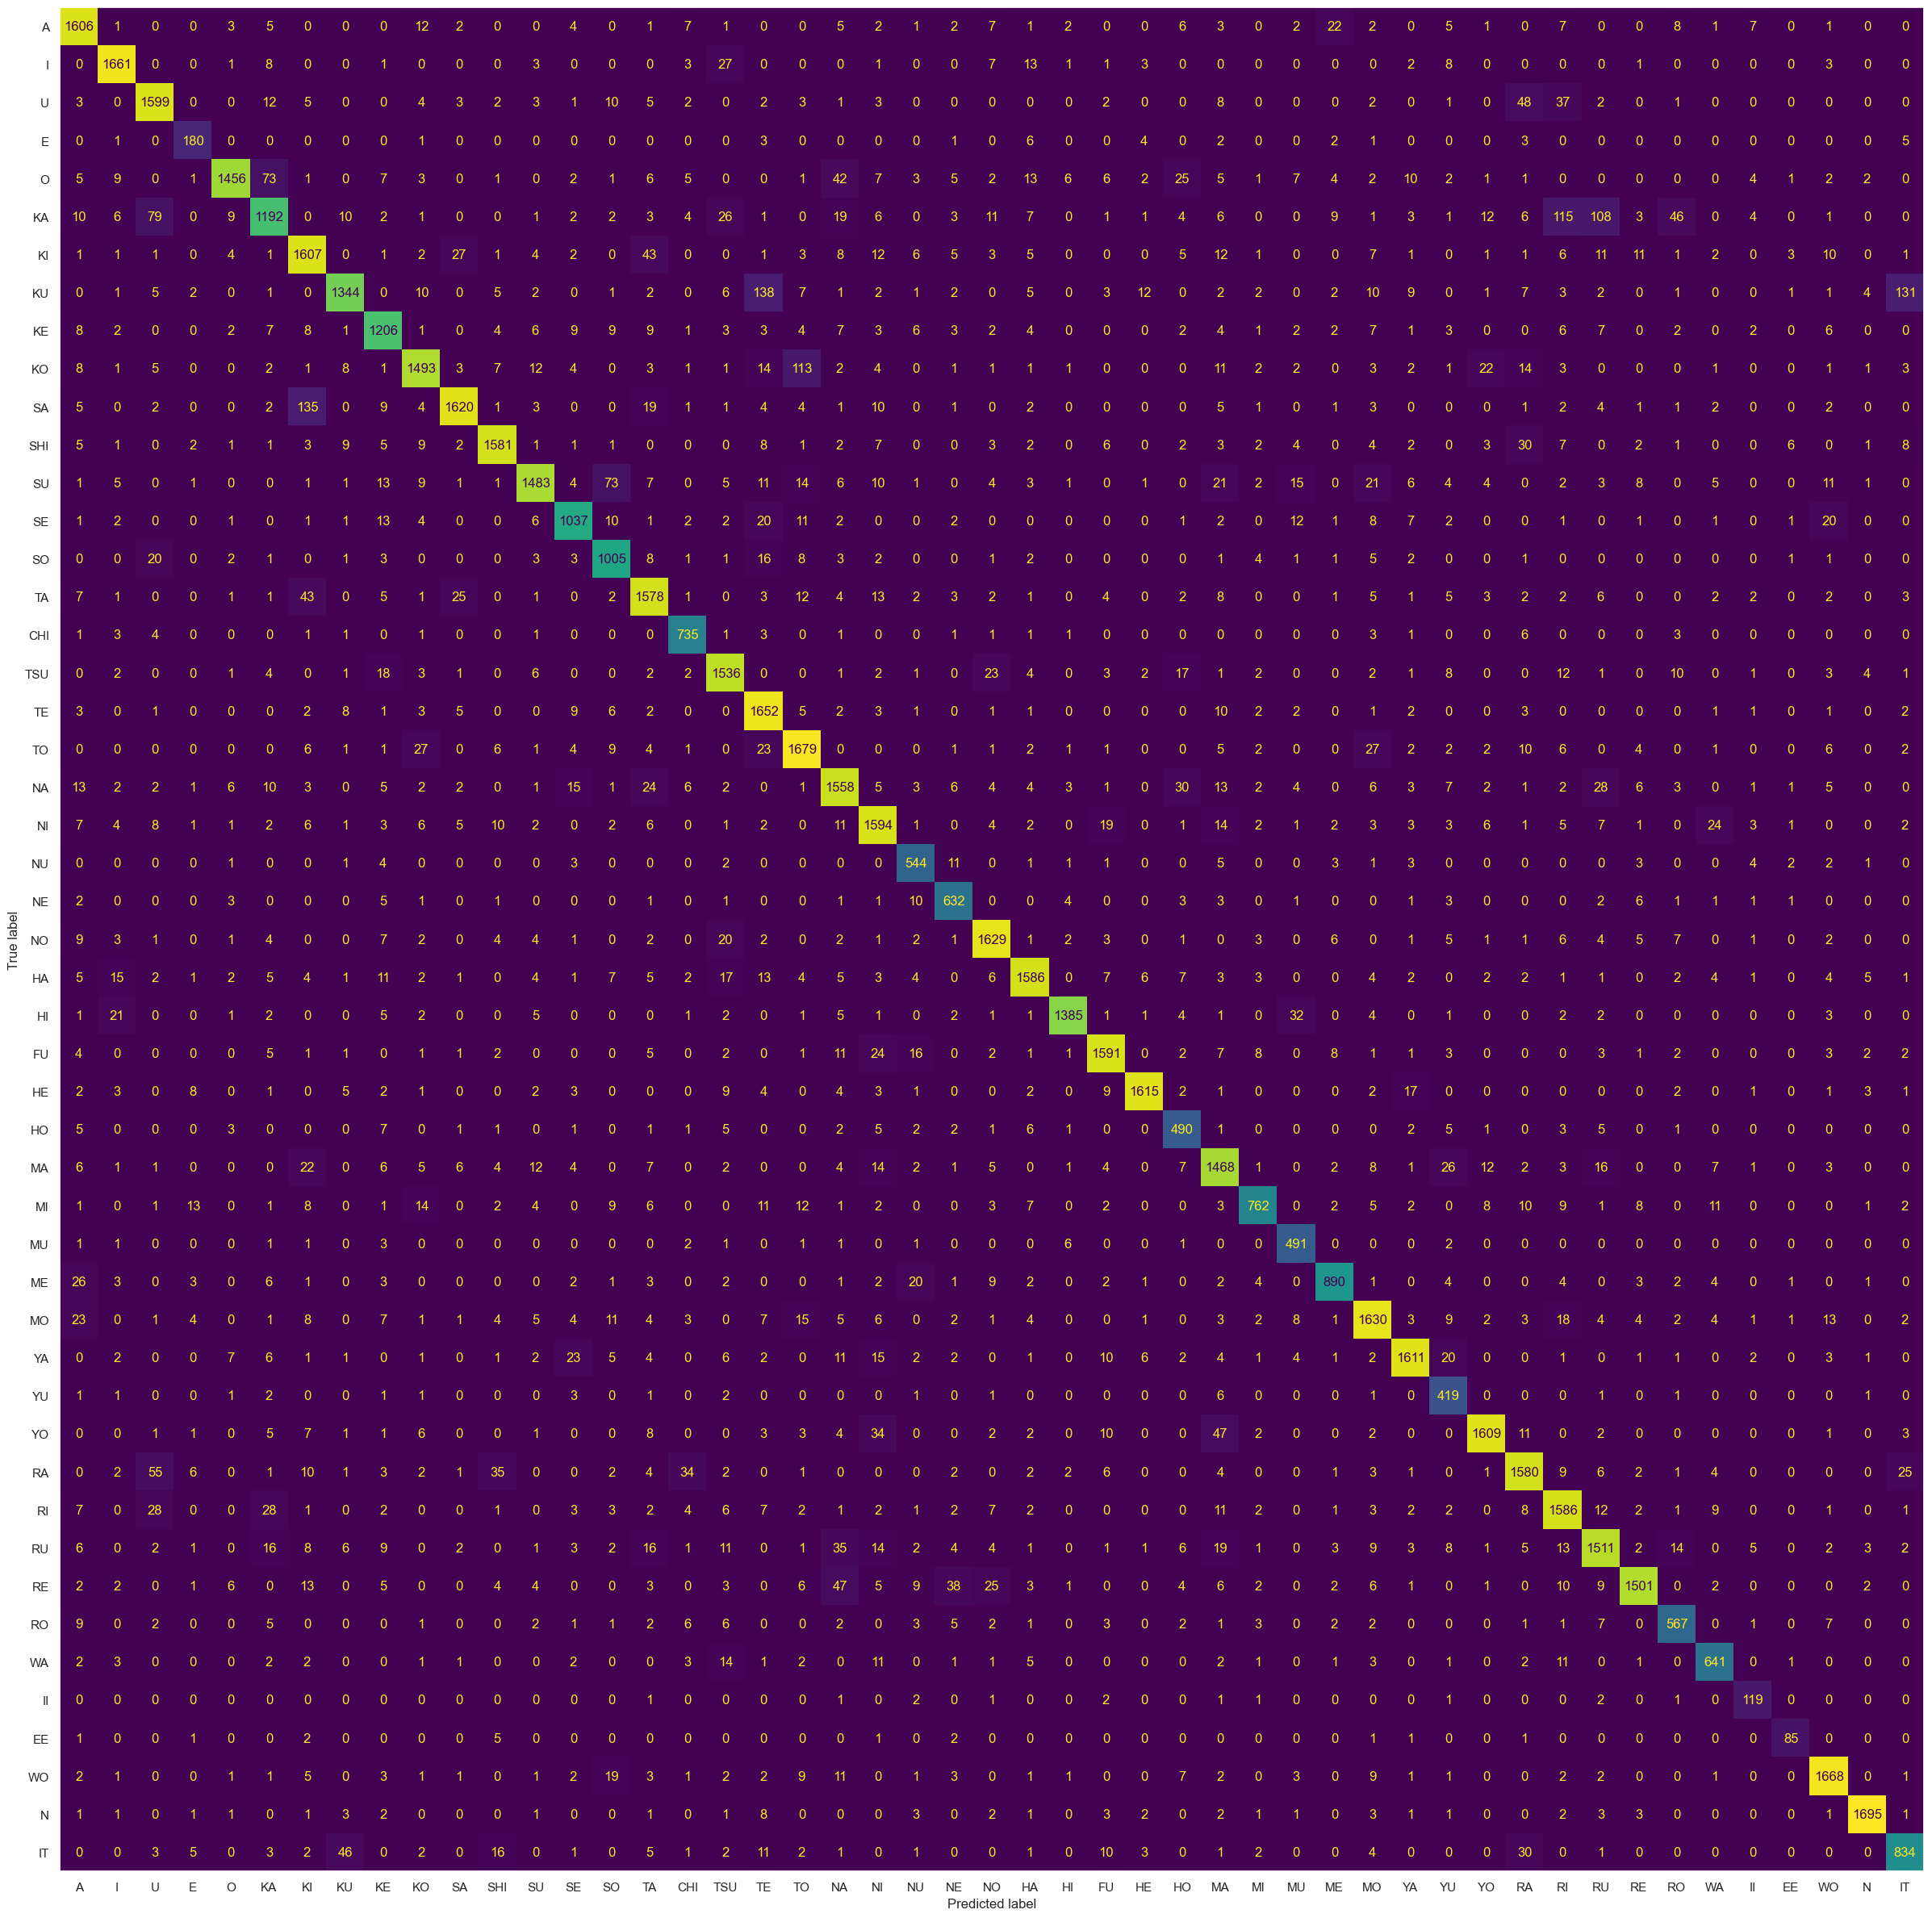

In [68]:
_, ax = plt.subplots(figsize=(30, 30))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=label_description, ax=ax, colorbar=False)

##### Balanced accuracy

In [69]:
ba = BalancedAccuracy(N_CLASSES)
ba(y_test, model2.predict(X_test2))

2117/2117 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step


<tf.Tensor: shape=(), dtype=float32, numpy=0.8944382667541504>

In [70]:
accuracy = y_test == y_pred
np.mean([np.mean(accuracy[y_test == i]) for i in range(49)])

np.float64(0.8944382580352068)